# Advanced Task 1: Term Deposit Subscription Prediction
**Objective:** Predict whether a customer will subscribe to a term deposit after a marketing campaign.
**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)
**Tools:** Python, pandas, numpy, scikit-learn, matplotlib, seaborn, shap

In [12]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score

# SHAP for Explainable AI
import shap

In [13]:
# Load dataset
df = pd.read_csv(r"C:\\Users\\Akhter Laptops\\Documents\\GitDemo\\data-science-internship\\dataset\\bank_marketing.csv")

# Preview dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Dataset Overview
- The dataset contains customer information and marketing campaign results.
- Key columns:
    - `age`, `job`, `marital`, `education`, `default`, `balance`, `housing`, `loan`, `contact`, `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`, `y`
- Target column: `y` (yes=customer subscribed, no=did not subscribe)

In [14]:
# Check for missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
# Encode categorical features
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Check after encoding
df.head()

C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_7016\997762158.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


In [16]:
# Features and target
X = df.drop("y", axis=1)
y = df['y']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)

c:\Users\Akhter Laptops\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

In [19]:
# Confusion Matrix & F1 Score
print("Logistic Regression:\n")
print(confusion_matrix(y_test, lr_preds))
print("\nF1 Score:", f1_score(y_test, lr_preds))

print("\nRandom Forest:\n")
print(confusion_matrix(y_test, rf_preds))
print("\nF1 Score:", f1_score(y_test, rf_preds))

Logistic Regression:

[[788  19]
 [ 82  16]]

F1 Score: 0.24060150375939848

Random Forest:

[[790  17]
 [ 72  26]]

F1 Score: 0.36879432624113473


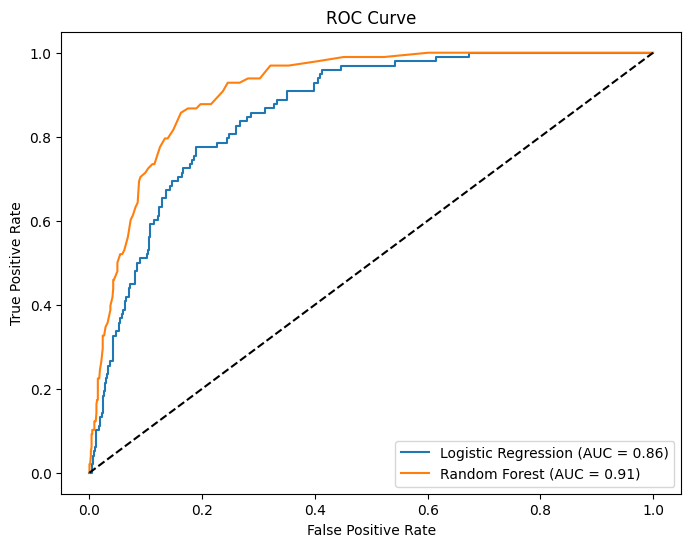

In [20]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
lr_probs = lr_model.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
rf_probs = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

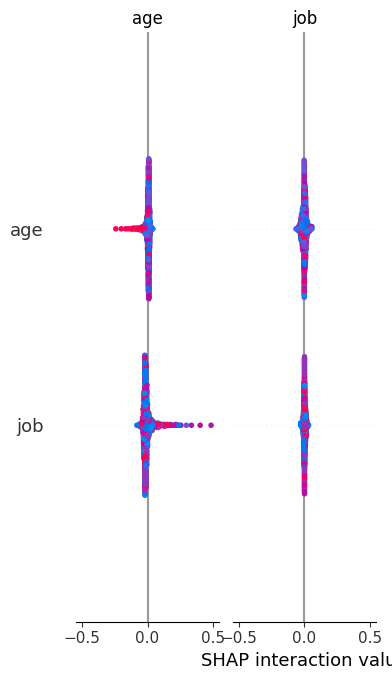

In [22]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

## Key Insights from SHAP
- The features with the most impact on subscription prediction:
    - `duration`, `poutcome`, `balance`, `campaign`, `age`
- Higher call duration, previous positive outcomes, and higher account balance increase likelihood of subscription.
- Marketing strategy can focus on these key features.